## Analysis For Maximizing Crop Yield via Nutrient Management

#### Problem Statement : 
Greenhouse farming provides a controlled environment for crop cultivation, but crop yield can vary significantly due to environmental conditions, irrigation practices, nutrient management, and pest pressure. The objective of this analysis is to identify the key factors affecting crop yield and develop data-driven recommendations to maximize yield per square meter while optimizing resource utilization within greenhouse operations.

#### KPQ:
1) Which crop type produces the highest yield?
2) Which variety performs best within each crop type?
3) How does yield vary across greenhouses?
4) What combination of N, P, and K maximizes yield?
5) How does humidity influence yield?
6) Can yield be accurately predicted using environmental and nutrient variables?
7) Which features are the strongest predictors of yield?

#### Project Workflow
1) Import Libraries
2) Load Dataset
3) Data Understanding
4) Data Cleaning & Preprocessing
5) Exploratory Data Analysis (EDA)
6) Feature Engineering (if required)
7) Correlation Analysis
8) Model Building using Linear Regression
9) Model Evaluation
10) Conclusions and Recommendations

In [1]:
# Import required Libraries
import pandas as pd 
import numpy as np

#Visualization Libraries

import matplotlib.pyplot as plt
import seaborn as sns

#predictive models

import scipy.stats as stats
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
#Load the dataset
try:
    data = pd.read_csv("data/greenhouse_crop_yields.csv")
    print("Data successfully Loaded")

except FileNotFoundError as e:
    print(f'File error is {e}')

Data successfully Loaded


In [3]:
data.head()

,greenhouse_id,crop_type,variety,planting_date,harvest_date,days_to_maturity,avg_temperature_C,min_temperature_C,max_temperature_C,humidity_percent,co2_ppm,light_intensity_lux,photoperiod_hours,irrigation_mm,fertilizer_N_kg_ha,fertilizer_P_kg_ha,fertilizer_K_kg_ha,pest_severity,soil_pH,yield_kg_per_m2
0,1.0,Tomato,Beefsteak,2023-11-02,2024-01-08,67.0,27.6,25.8,30.6,73.6,917.0,16821.0,10.0,9.8,167.0,74.0,154.0,1.3,6.1,9.19
1,3.0,Cucumber,English,2023-11-01,2024-01-03,63.0,24.4,21.0,27.3,80.8,782.0,27483.0,10.0,9.2,174.0,82.0,126.0,3.2,6.3,7.42
2,5.0,Tomato,Beefsteak,2023-02-02,2023-04-19,76.0,23.9,20.6,26.0,76.6,821.0,30516.0,10.0,7.0,234.0,64.0,243.0,1.2,6.0,20.86
3,5.0,Tomato,Heirloom,2023-07-29,2023-10-21,84.0,26.7,25.5,29.6,76.1,710.0,43580.0,15.1,5.4,167.0,63.0,234.0,0.8,6.0,22.09
4,4.0,Cucumber,Slicing,2023-02-07,2023-04-15,67.0,24.1,22.4,26.5,69.8,921.0,22283.0,10.0,8.4,102.0,98.0,173.0,1.1,7.4,6.42


In [4]:
data.describe()

,greenhouse_id,days_to_maturity,avg_temperature_C,min_temperature_C,max_temperature_C,humidity_percent,co2_ppm,light_intensity_lux,photoperiod_hours,irrigation_mm,fertilizer_N_kg_ha,fertilizer_P_kg_ha,fertilizer_K_kg_ha,pest_severity,soil_pH,yield_kg_per_m2
count,10400.000000,10400.000000,9858.000000,9858.000000,9858.000000,9858.000000,9827.000000,9858.000000,10400.000000,10400.000000,9342.000000,9342.000000,9342.000000,10276.000000,10098.000000,10400.000000
mean,3.013077,64.519327,23.421627,21.529580,25.306868,74.972327,799.832095,30045.450193,12.457529,7.003212,163.441661,71.442518,166.801006,1.831666,6.505070,12.381656
std,1.417617,16.392426,3.401036,3.473755,3.455992,8.582842,148.809930,8086.985394,2.308943,1.982951,42.012956,21.597035,39.775813,1.448331,0.500929,4.961302
min,1.000000,29.000000,10.600000,8.400000,12.000000,47.200000,348.000000,5000.000000,9.800000,1.000000,80.000000,30.000000,80.000000,-0.200000,5.000000,0.100000
25%,2.000000,53.000000,21.700000,19.700000,23.500000,68.900000,698.000000,24016.750000,10.000000,5.600000,130.000000,55.000000,137.000000,0.600000,6.200000,8.567500
50%,3.000000,65.000000,24.100000,22.200000,25.900000,75.000000,800.000000,30106.500000,12.100000,7.000000,163.000000,69.000000,167.000000,1.600000,6.500000,11.905000
75%,4.000000,77.000000,25.800000,24.000000,27.700000,81.200000,903.000000,36075.750000,14.800000,8.400000,194.000000,87.000000,194.000000,2.800000,6.800000,15.750000
max,5.000000,100.000000,32.000000,30.400000,34.200000,100.000000,1200.000000,57094.000000,16.200000,13.500000,250.000000,121.000000,250.000000,6.700000,8.000000,30.640000


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10400 entries, 0 to 10399
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   greenhouse_id        10400 non-null  float64
 1   crop_type            10400 non-null  object 
 2   variety              10400 non-null  object 
 3   planting_date        10400 non-null  object 
 4   harvest_date         10400 non-null  object 
 5   days_to_maturity     10400 non-null  float64
 6   avg_temperature_C    9858 non-null   float64
 7   min_temperature_C    9858 non-null   float64
 8   max_temperature_C    9858 non-null   float64
 9   humidity_percent     9858 non-null   float64
 10  co2_ppm              9827 non-null   float64
 11  light_intensity_lux  9858 non-null   float64
 12  photoperiod_hours    10400 non-null  float64
 13  irrigation_mm        10400 non-null  float64
 14  fertilizer_N_kg_ha   9342 non-null   float64
 15  fertilizer_P_kg_ha   9342 non-null  

In [6]:
# lets handle Missing Data 
data.isnull().sum()

greenhouse_id             0
crop_type                 0
variety                   0
planting_date             0
harvest_date              0
days_to_maturity          0
avg_temperature_C       542
min_temperature_C       542
max_temperature_C       542
humidity_percent        542
co2_ppm                 573
light_intensity_lux     542
photoperiod_hours         0
irrigation_mm             0
fertilizer_N_kg_ha     1058
fertilizer_P_kg_ha     1058
fertilizer_K_kg_ha     1058
pest_severity           124
soil_pH                 302
yield_kg_per_m2           0
dtype: int64

Approximately 10% missing values were present. Since the missing proportion was relatively low, rows with missing observations were removed to simplify analysis.

In [7]:
#we have nearly 10% of data missing we can remove the data.

data = data.dropna(axis=0)
data.isna().sum()

greenhouse_id          0
crop_type              0
variety                0
planting_date          0
harvest_date           0
days_to_maturity       0
avg_temperature_C      0
min_temperature_C      0
max_temperature_C      0
humidity_percent       0
co2_ppm                0
light_intensity_lux    0
photoperiod_hours      0
irrigation_mm          0
fertilizer_N_kg_ha     0
fertilizer_P_kg_ha     0
fertilizer_K_kg_ha     0
pest_severity          0
soil_pH                0
yield_kg_per_m2        0
dtype: int64

In [8]:
# We will look for duplicate Values

data.duplicated().sum()

162

In [9]:
data = data.drop_duplicates().reset_index(drop=True)

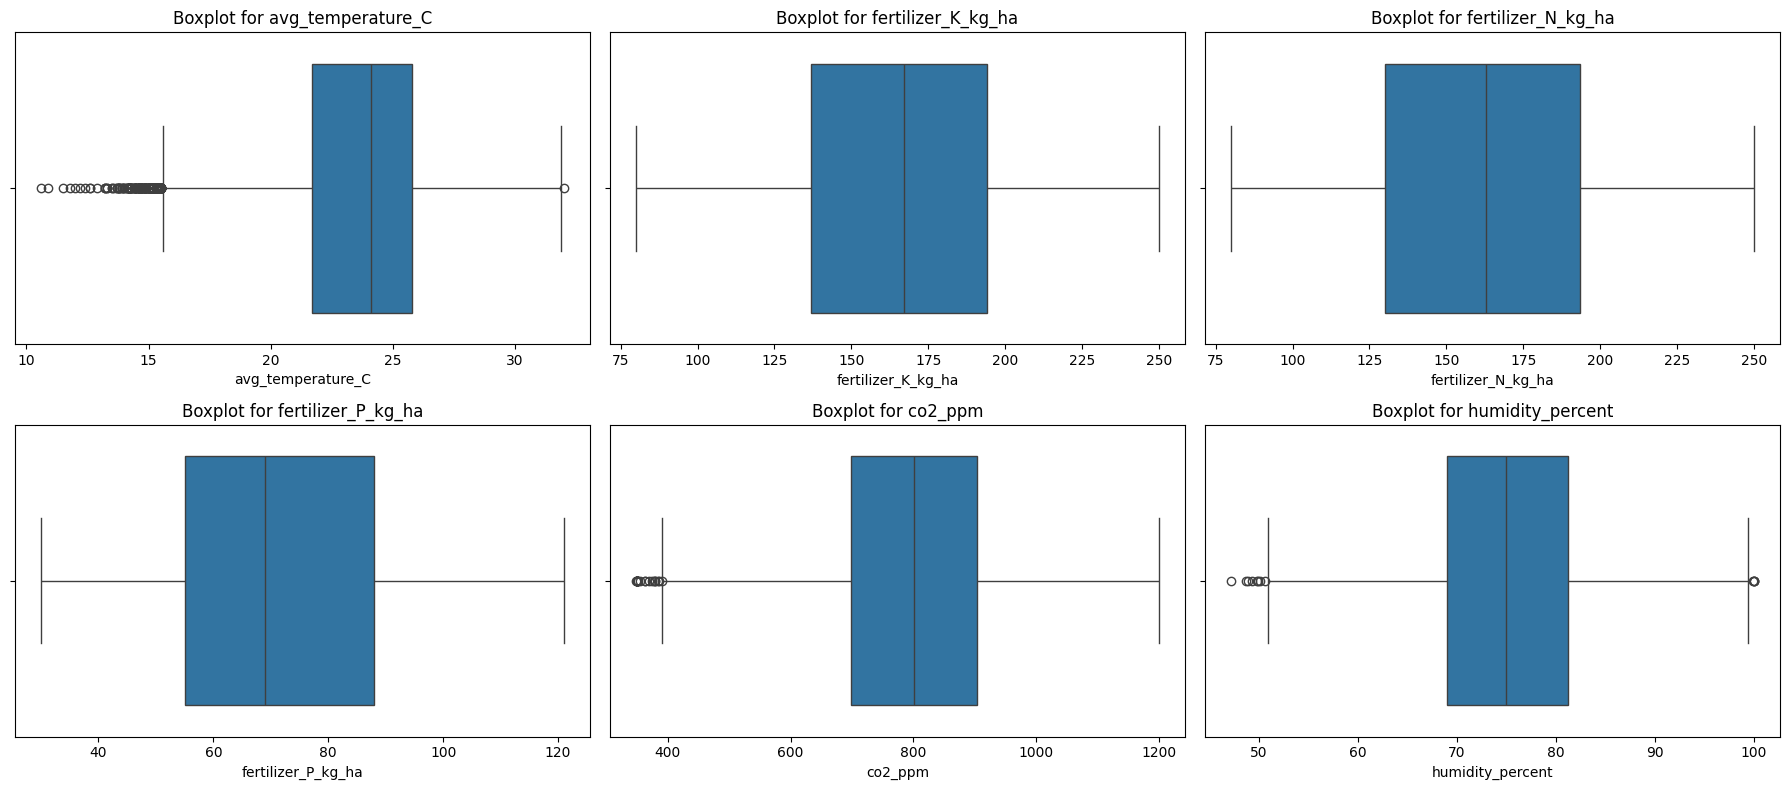

In [10]:
#Lets Look for data distribution and outliers

fig, ax = plt.subplots(2,3,figsize = (18,8))
sns.boxplot(x = data['avg_temperature_C'],ax=ax[0,0])
ax[0,0].set_title('Boxplot for avg_temperature_C')
sns.boxplot(x = data['fertilizer_K_kg_ha'],ax=ax[0,1])
ax[0,1].set_title('Boxplot for fertilizer_K_kg_ha')
sns.boxplot(x = data['fertilizer_N_kg_ha'],ax=ax[0,2])
ax[0,2].set_title('Boxplot for fertilizer_N_kg_ha')
sns.boxplot(x = data['fertilizer_P_kg_ha'],ax=ax[1,0])
ax[1,0].set_title('Boxplot for fertilizer_P_kg_ha')
sns.boxplot(x = data['co2_ppm'],ax=ax[1,1])
ax[1,1].set_title('Boxplot for co2_ppm')
sns.boxplot(x = data['humidity_percent'],ax=ax[1,2])
ax[1,2].set_title('Boxplot for humidity_percent')
plt.tight_layout()

Text(0.5, 1.0, 'Boxplot for yield_kg_per_m2')

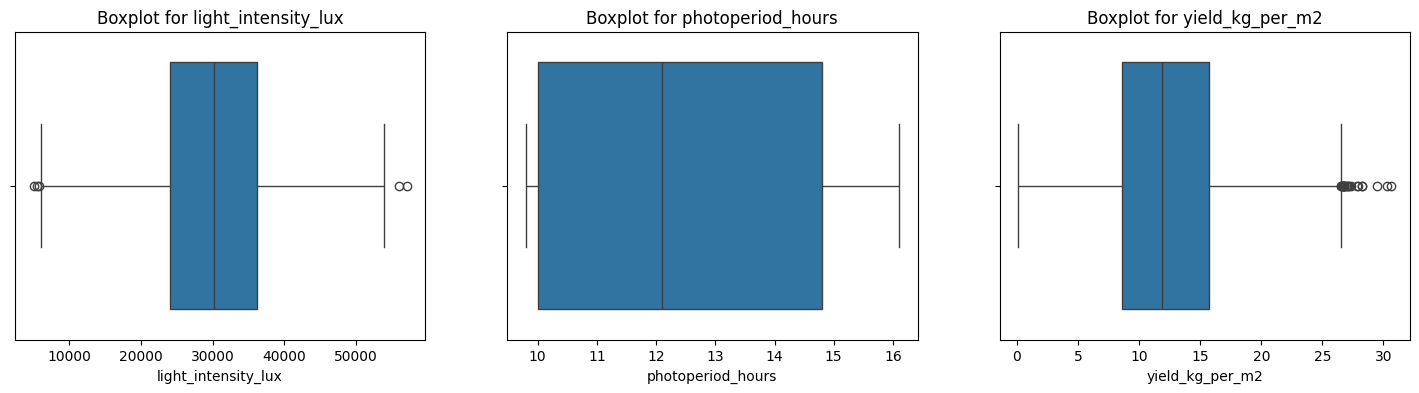

In [11]:
fig, ax = plt.subplots(1,3,figsize = (18,4))
sns.boxplot(x = data['light_intensity_lux'],ax=ax[0])
ax[0].set_title('Boxplot for light_intensity_lux')
sns.boxplot(x = data['photoperiod_hours'],ax=ax[1])
ax[1].set_title('Boxplot for photoperiod_hours')
sns.boxplot(x = data['yield_kg_per_m2'],ax=ax[2])
ax[2].set_title('Boxplot for yield_kg_per_m2')

In [12]:
# we have some outliers in some columns we are going to take care for that

def outlier_impute(column):
    for col in column:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)

        IQR = Q3-Q1

        upper_limit = Q3 + (IQR*1.5)
        lower_limit = Q1- (IQR*1.5)

        data.loc[data[col]>upper_limit,col]=upper_limit
        data.loc[data[col]<lower_limit,col]=lower_limit


In [13]:
column_list = ['avg_temperature_C','co2_ppm','humidity_percent','light_intensity_lux']
outlier_impute(column_list)

Boxplots revealed outliers in `avg_temperature_C`, `co2_ppm`, `humidity_percent`,
`light_intensity_lux`.We applied **IQR-based capping** — values beyond Q1 - 1.5×IQR or Q3 + 1.5×IQR
are clipped to the boundary rather than removed. This preserves all rows while limiting the
influence of extreme values on the regression model.

#### 1) Which crop type produces the highest yield?

In [14]:
data.groupby(['crop_type'])[['yield_kg_per_m2']].mean().sort_values(by ='yield_kg_per_m2',ascending=False)

,yield_kg_per_m2
crop_type,
Tomato,16.650470
Cucumber,11.346500
Pepper,8.747659
Lettuce,7.278910


The table above ranks crop types by average yield per m².
**Tomatoes** produce the highest average yield i.e. 16.64 kg per m2, followed by cucumber and Pepper.
This can guide greenhouse managers in prioritizing high-value crops for cultivation.

#### 2) Which variety performs best within each crop type?

In [15]:
data.groupby(['crop_type','variety'])[['yield_kg_per_m2']].mean().sort_values(by ='yield_kg_per_m2',ascending=False)

yield_kg_per_m2
crop_type variety                    
Tomato    Roma              16.711387
          Heirloom          16.708327
          Beefsteak         16.633643
          Cherry            16.548103
Cucumber  Slicing           11.409964
          Pickling          11.401452
          English           11.233474
Pepper    Bell               8.959808
          Habanero           8.730258
          Jalapeno           8.571771
Lettuce   Leaf               7.343195
          Butterhead         7.295547
          Iceberg            7.244159
          Romaine            7.230120

Within each crop type, yield doen't varies meaningfully across varieties. but they varies among croptype significantly. 
Selecting the right variety is a low-cost, high-impact lever for improving total output.

#### 3) How does yield vary across greenhouses?

In [16]:
data.groupby(['greenhouse_id'])[['yield_kg_per_m2']].mean().sort_values(by ='yield_kg_per_m2',ascending=False)

,yield_kg_per_m2
greenhouse_id,
1.0,12.519191
2.0,12.423564
3.0,12.385248
5.0,12.268245
4.0,12.189928


Yield differences between greenhouses are relatively small (approximately 0.33 kg/m² between highest and lowest average yield), suggesting consistent operational performance.

#### 5) How does humidity or Temperature influence yield?


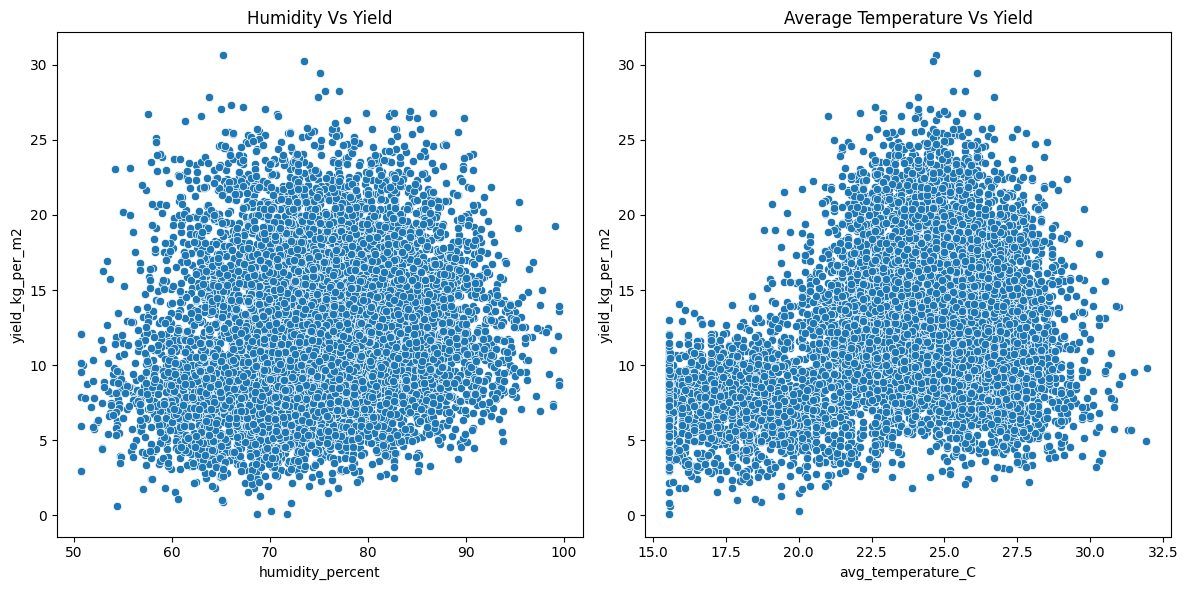

In [17]:
fig , ax = plt.subplots(1,2,figsize=(12,6))
sns.scatterplot(x =data['humidity_percent'],y=data['yield_kg_per_m2'],ax=ax[0])
ax[0].set_title("Humidity Vs Yield")
sns.scatterplot(x =data['avg_temperature_C'],y=data['yield_kg_per_m2'],ax=ax[1])
ax[1].set_title("Average Temperature Vs Yield")
plt.tight_layout()
plt.show()

Scatterplots suggest yield tends to be higher around humidity levels of 70–80% and temperatures between 22–28°C, although further statistical testing would be needed to confirm optimal operating ranges.

So if you see the units for the N,K,P those are kg per hectore where as yield is Kg per m2 so we are going to convert the units. so all units are going to be same for calculation ease.

In [18]:
data['yield_kg_per_ha'] = data['yield_kg_per_m2']*10000

In [19]:
data = data.drop(columns=['yield_kg_per_m2'],axis=1)
data.head()

,greenhouse_id,crop_type,variety,planting_date,harvest_date,days_to_maturity,avg_temperature_C,min_temperature_C,max_temperature_C,humidity_percent,co2_ppm,light_intensity_lux,photoperiod_hours,irrigation_mm,fertilizer_N_kg_ha,fertilizer_P_kg_ha,fertilizer_K_kg_ha,pest_severity,soil_pH,yield_kg_per_ha
0,1.0,Tomato,Beefsteak,2023-11-02,2024-01-08,67.0,27.6,25.8,30.6,73.6,917.0,16821.0,10.0,9.8,167.0,74.0,154.0,1.3,6.1,91900.0
1,3.0,Cucumber,English,2023-11-01,2024-01-03,63.0,24.4,21.0,27.3,80.8,782.0,27483.0,10.0,9.2,174.0,82.0,126.0,3.2,6.3,74200.0
2,5.0,Tomato,Beefsteak,2023-02-02,2023-04-19,76.0,23.9,20.6,26.0,76.6,821.0,30516.0,10.0,7.0,234.0,64.0,243.0,1.2,6.0,208600.0
3,5.0,Tomato,Heirloom,2023-07-29,2023-10-21,84.0,26.7,25.5,29.6,76.1,710.0,43580.0,15.1,5.4,167.0,63.0,234.0,0.8,6.0,220900.0
4,4.0,Cucumber,Slicing,2023-02-07,2023-04-15,67.0,24.1,22.4,26.5,69.8,921.0,22283.0,10.0,8.4,102.0,98.0,173.0,1.1,7.4,64200.0


#### 4) What combination of N, P, and K maximizes yield?


In [20]:
data_extract = data[['fertilizer_N_kg_ha','fertilizer_P_kg_ha','fertilizer_K_kg_ha','yield_kg_per_ha']]

data_extract.sort_values(by='yield_kg_per_ha',ascending=False)

,fertilizer_N_kg_ha,fertilizer_P_kg_ha,fertilizer_K_kg_ha,yield_kg_per_ha
7707,217.0,119.0,203.0,306400.0
7747,230.0,115.0,173.0,302800.0
7919,233.0,86.0,156.0,294700.0
8251,233.0,92.0,174.0,282700.0
484,230.0,98.0,194.0,282400.0
...,...,...,...,...
4324,148.0,34.0,86.0,8000.0
3052,140.0,56.0,138.0,5800.0
7695,102.0,35.0,117.0,3000.0
2461,115.0,33.0,143.0,1000.0


High-yield records frequently occur alongside higher Nitrogen and Potassium application rates, suggesting a positive association. Controlled experimentation would be required to identify optimal fertilizer combinations.

In [21]:
#Lets find out relations between features.
corr_matrix = data.corr(numeric_only=True)

<Axes: >

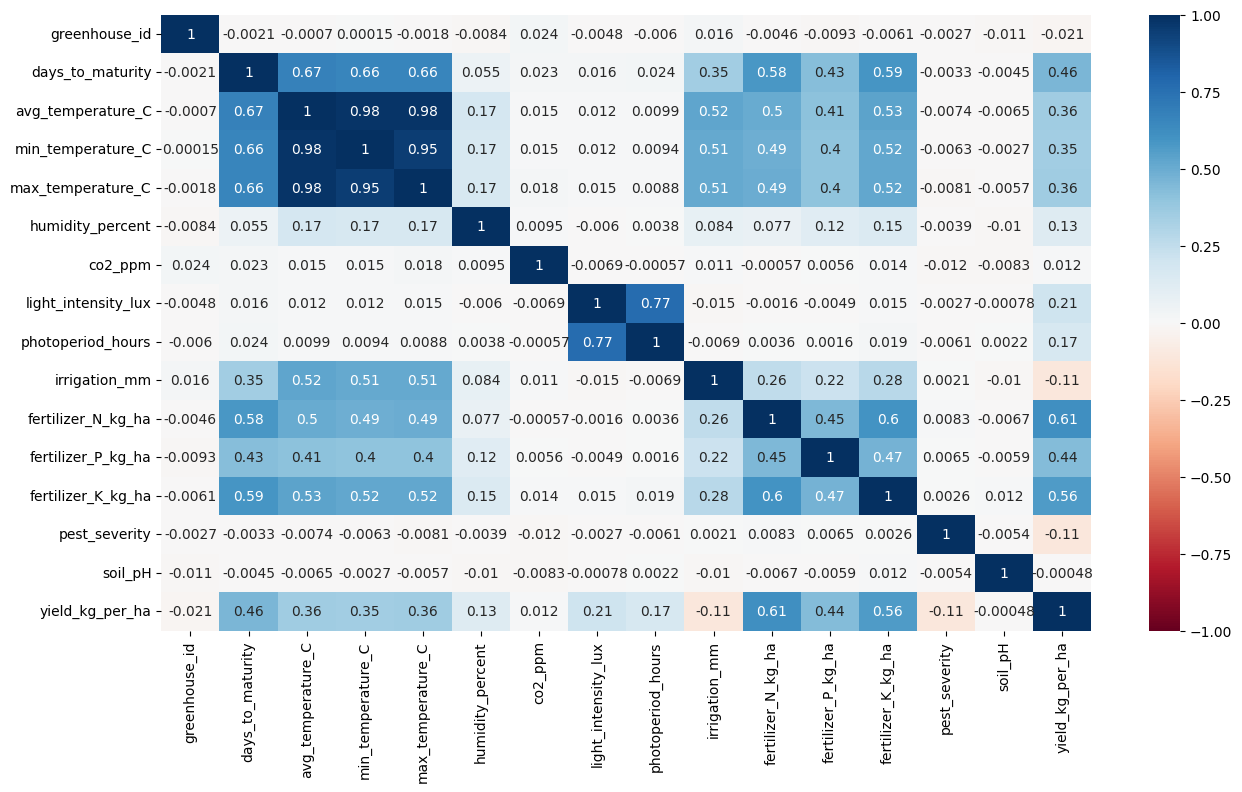

In [22]:
plt.figure(figsize=(15,8))
sns.heatmap(data=corr_matrix,annot=True,vmax=1,vmin=-1,cmap="RdBu")

In [23]:
# lets encode String variable
categorical_cols = [
    'crop_type',
    'greenhouse_id',
    'variety'
]


In [24]:
# Filter out Features and Target Variable 

y = data[['yield_kg_per_ha']]
X = data.drop(columns=['yield_kg_per_ha','planting_date','harvest_date'])

In [25]:
X = pd.get_dummies(X,columns=categorical_cols,drop_first=True,dtype="uint8")

In [26]:
#Train test split
X_Train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [27]:
scaler = StandardScaler()
X_train_trans = scaler.fit_transform(X_Train)
X_test_trans = scaler.transform(X_test)

In [28]:
lr = LinearRegression()
model = lr.fit(X_train_trans,y_train)

In [29]:
pred = model.predict(X_test_trans)

r2 = round(r2_score(y_test,pred),2)
mae = round(mean_absolute_error(y_test,pred),2)
rmse = round(np.sqrt(mean_squared_error(y_test,pred)),2)
perc_rmse = round((np.sqrt(mean_squared_error(y_test,pred)) / y['yield_kg_per_ha'].mean()) * 100,2)
print("R2 :",r2)
print("MAE :",mae)
print("RMSE :",rmse)
print("rmse_percent = ",perc_rmse)

R2 : 0.76
MAE : 19087.39
RMSE : 24328.13
rmse_percent =  19.69


In [30]:
y_train_pred = model.predict(X_train_trans)

r2_train = round(r2_score(y_train,y_train_pred),2)
mae_train = round(mean_absolute_error(y_train,y_train_pred),2)
rmse_train = round(np.sqrt(mean_squared_error(y_train,y_train_pred)),2)
perc_rmse_train = round((np.sqrt(mean_squared_error(y_train,y_train_pred)) / y['yield_kg_per_ha'].mean()) * 100,2)
print("R2 :",r2_train)
print("MAE :",mae_train)
print("RMSE :",rmse_train)
print("rmse_percent = ",perc_rmse_train)


R2 : 0.77
MAE : 18977.69
RMSE : 23913.03
rmse_percent =  19.35


In [31]:
result_df  = pd.DataFrame({
    "Metric":['Train','Test'],
    "R2":[r2_train,r2],
    "MAE":[mae_train,mae],
    'RMSE':[rmse_train,rmse],
    "RMSE_Percentage":[perc_rmse_train,perc_rmse]
})

result_df

,Metric,R2,MAE,RMSE,RMSE_Percentage
0,Train,0.77,18977.69,23913.03,19.35
1,Test,0.76,19087.39,24328.13,19.69


From Training and Testing R2 score we can conclude that our model is not Overfit

In [32]:
# Extract the intercept and coefficients
intercept = model.intercept_
coefficients = model.coef_

print(f"Intercept: {intercept}")
print(f"Coefficients: {coefficients}")

Intercept: [123560.74696508]
Coefficients: [[-7.58367419e+02 -5.33828752e+03  1.70268502e+03  5.00344629e+03
  -1.58482719e+01  1.31609020e+02  9.78361328e+03 -7.57404505e+01
  -2.01145044e+04  7.50187889e+03  3.87214006e+01 -1.70610572e+02
  -6.06705550e+03 -3.52785970e+02  9.25987883e+15 -3.17813204e+17
  -4.81607356e+16 -3.88131593e+02 -2.21574910e+02 -6.15455808e+02
  -6.25423402e+02  1.70653089e+17 -2.67328858e+16  9.18460521e+00
  -3.04689483e+16  1.69857001e+17  2.00754870e+02 -2.66954236e+16
   1.76875189e+17 -2.72506609e+16 -2.99119899e+16 -1.84565442e+02
  -2.63552957e+16 -2.99119899e+16]]


In [33]:
# Create a clean DataFrame mapping features to their coefficients
coef_summary = pd.DataFrame({
    'Feature': X_Train.columns,
    'Coefficient':np.ravel(model.coef_)
})
coef_summary.sort_values(by='Coefficient',ascending=False)

,Feature,Coefficient
28,variety_Jalapeno,1.768752e+17
21,variety_Bell,1.706531e+17
25,variety_Habanero,1.698570e+17
14,crop_type_Lettuce,9.259879e+15
6,light_intensity_lux,9.783613e+03
9,fertilizer_N_kg_ha,7.501879e+03
3,max_temperature_C,5.003446e+03
2,min_temperature_C,1.702685e+03
26,variety_Heirloom,2.007549e+02
5,co2_ppm,1.316090e+02



#### 6 & 7) Can yield be accurately predicted using environmental and nutrient variables? Which features are the strongest predictors?

1) The Linear Regression model achieved: Training R2 = 0.77 and Testing R² = 0.76.
This indicates that approximately 76% of yield variation can be explained by the available environmental, nutrient, and crop-related variables.
2) High yield performance is associated with high Nitrogen (~170–210 kg/ha), moderate Phosphorus (~65–80 kg/ha), and high Potassium (~180–230 kg/ha).
3) Yes, yield can be predicted using these metrics. The primary drivers are light intensity, Temperature variations (Min/Max), and Nitrogen (N) Application. Your linear model captures a baseline of this variance.

### Check Model assumptions

#### Model assumption: Linearity and Constant Variance(Homoscedasticity)

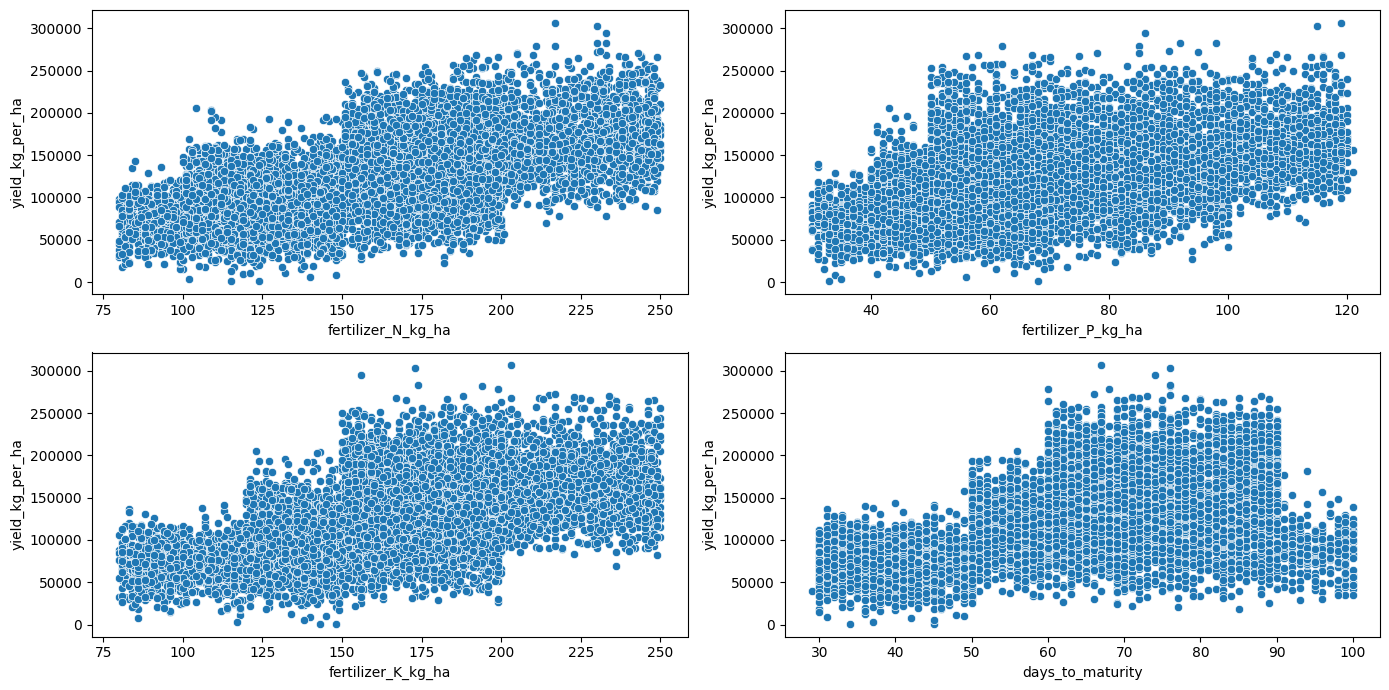

In [34]:
fig, ax  = plt.subplots(2,2,figsize=(14,7))
sns.scatterplot(x= data['fertilizer_N_kg_ha'],y=data['yield_kg_per_ha'],ax = ax[0,0])
sns.scatterplot(x= data['fertilizer_P_kg_ha'],y=data['yield_kg_per_ha'],ax = ax[0,1])
sns.scatterplot(x= data['fertilizer_K_kg_ha'],y=data['yield_kg_per_ha'],ax = ax[1,0])
sns.scatterplot(x= data['days_to_maturity'],y=data['yield_kg_per_ha'],ax = ax[1,1])
plt.tight_layout()

In [35]:
# lets plot the residual

residual  = y_test - pred
reshape_pred = np.ravel(pred)
reshape_residual = np.ravel(residual)


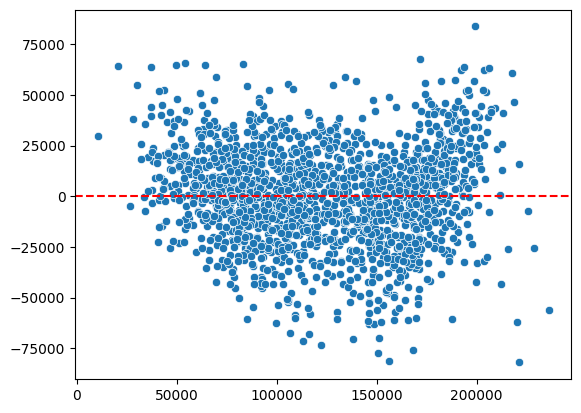

In [36]:
sns.scatterplot(x=reshape_pred,y=reshape_residual)
plt.axhline(y=0,color = 'red',linestyle = '--')

<Axes: xlabel='fertilizer_N_kg_ha', ylabel='yield_kg_per_ha'>

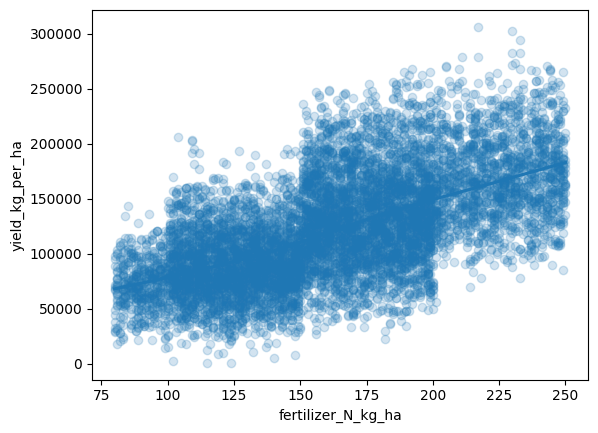

In [37]:
sns.regplot(
    data=data,
    x='fertilizer_N_kg_ha',
    y='yield_kg_per_ha',
    lowess=True,
    scatter_kws={'alpha':0.2}
)

The residuals vs fitted values plot should show points randomly scattered around the red line (y=0)
with no clear funnel or pattern. If the spread is roughly constant across all predicted values,
the assumptions of **linearity** and **constant variance (homoscedasticity)** are satisfied.

#### Model Assumption Check : Normality

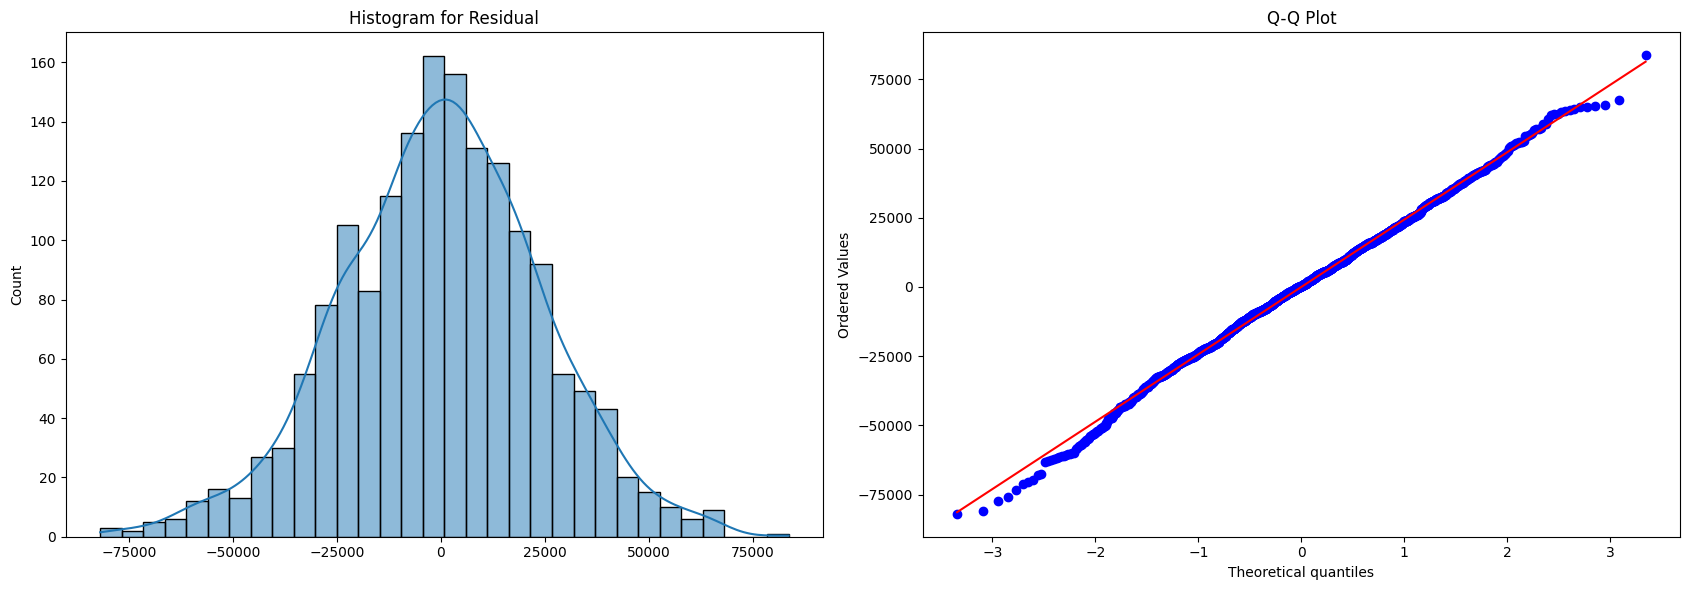

In [38]:
fig, ax =plt.subplots(1,2,figsize=(17,6))

sns.histplot(x=reshape_residual,kde=True,ax =ax[0])
ax[0].set_title('Histogram for Residual')
stats.probplot(reshape_residual,dist="norm",plot= ax[1])
ax[1].set_title("Q-Q Plot")
plt.tight_layout()
plt.show()

The histogram shows the distribution of residuals, and the Q-Q plot compares them against a
theoretical normal distribution. Points following the diagonal line closely indicate that residuals
are approximately normally distributed at the end of Q-Q plot it show some disturbance at end but that no too much model satisfied Normality

#### Model Assumption Check: Multicollinearity

In [40]:
#

vif_df = pd.DataFrame()

vif_df['Features'] = X.columns

vif_df['VIF'] = [variance_inflation_factor(X.values,i) for i in range(X.shape[1])]

vif_df.sort_values(by='VIF',ascending=True)

c:\Users\maneo\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Features,VIF
12,pest_severity,1.002790
5,co2_ppm,1.004209
13,soil_pH,1.004457
4,humidity_percent,1.272578
8,irrigation_mm,1.382912
10,fertilizer_P_kg_ha,1.575503
17,greenhouse_id_2.0,1.598892
18,greenhouse_id_3.0,1.600769
19,greenhouse_id_4.0,1.603591
20,greenhouse_id_5.0,1.604054


Variance Inflation Factor (VIF) measures how much a feature's variance is inflated due to
correlation with other features.

| VIF Range | Interpretation |
|-----------|----------------|
| < 5 | No multicollinearity |
| 5–10 | Moderate — monitor |
| > 10 | High — consider removing |

Features with VIF > 10 should be dropped or combined to improve model stability.

Strong multicollinearity exists between crop_type and variety because each variety belongs exclusively to one crop type. Some VIF values become extremely large or infinite, making coefficient interpretation unreliable. max-min temperature

The main goal of this project was to learn and demonstrate Linear Regression. In future work, one of the correlated features (crop_type or variety) could be removed, and models like Random Forest or Ridge Regression could be tested for further insights.

### Conclusion and Recommendations:

#### Key Findings:
1. **Tomato** consistently produces the highest yield — prioritize it in production planning.
2. **Humidity** and **temperature** have a clear influence — maintaining optimal ranges is critical.
3. The Linear Regression model achieved **R² = 0.76** on test data, explaining 76% of yield variance with an error of approximately 24268.61 kg/ha (~19.64% of mean yield).
4. **light intensity, Temperature variations (Min/Max), and Nitrogen (N)** are the strongest predictors of yield.

#### Business Recommendations:
- Allocate more greenhouse space to Heirloom Tomatoes and English Cucumbers to maximize output density.
- Standardize automated climate profiles across all facilities, targeting a strict humidity range of 70% to 80% and an average temperature around 24°C.
- Put a cap on Nitrogen applications at 200 kg/ha to cut resource costs without sacrificing output
- Move away from basic Linear Regression and implement a Random Forest Regressor or a Gradient Boosting Model (XGBoost) to better capture the curved, non-linear relationships between climate variables and crop yields.